In [ ]:
!pip install numpy matplotlib kaggle scipy

Mounted at /content/drive


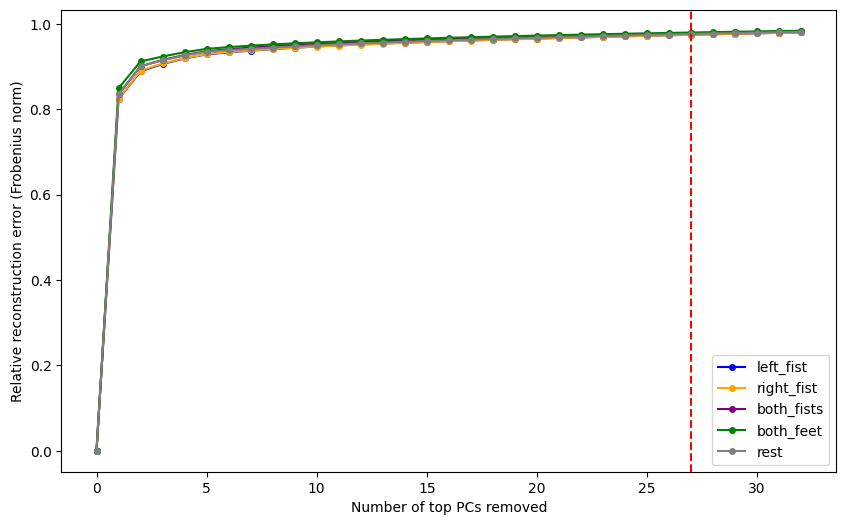

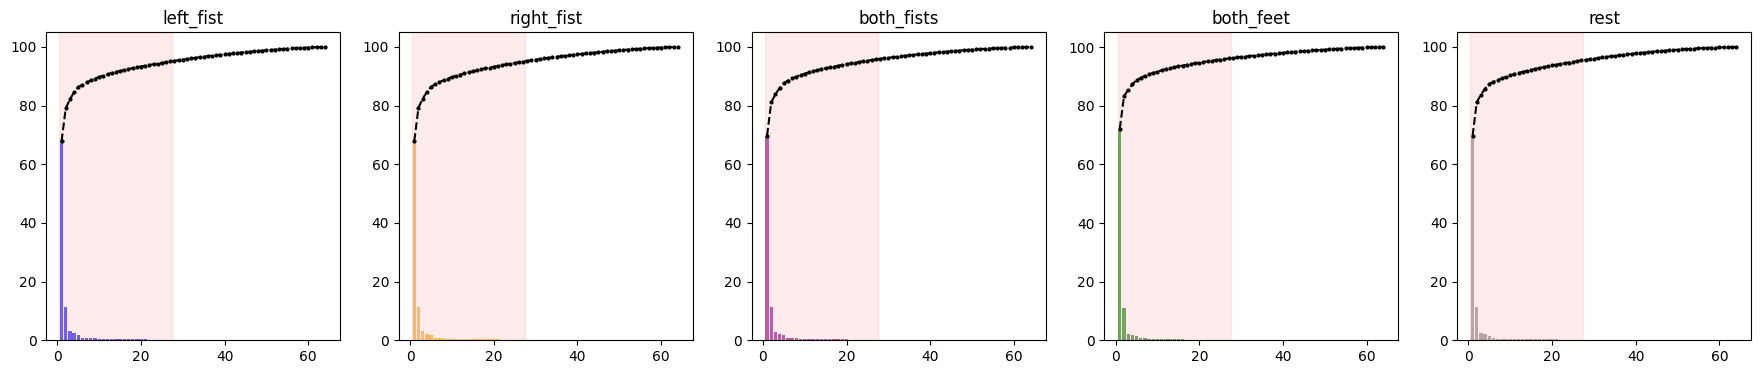

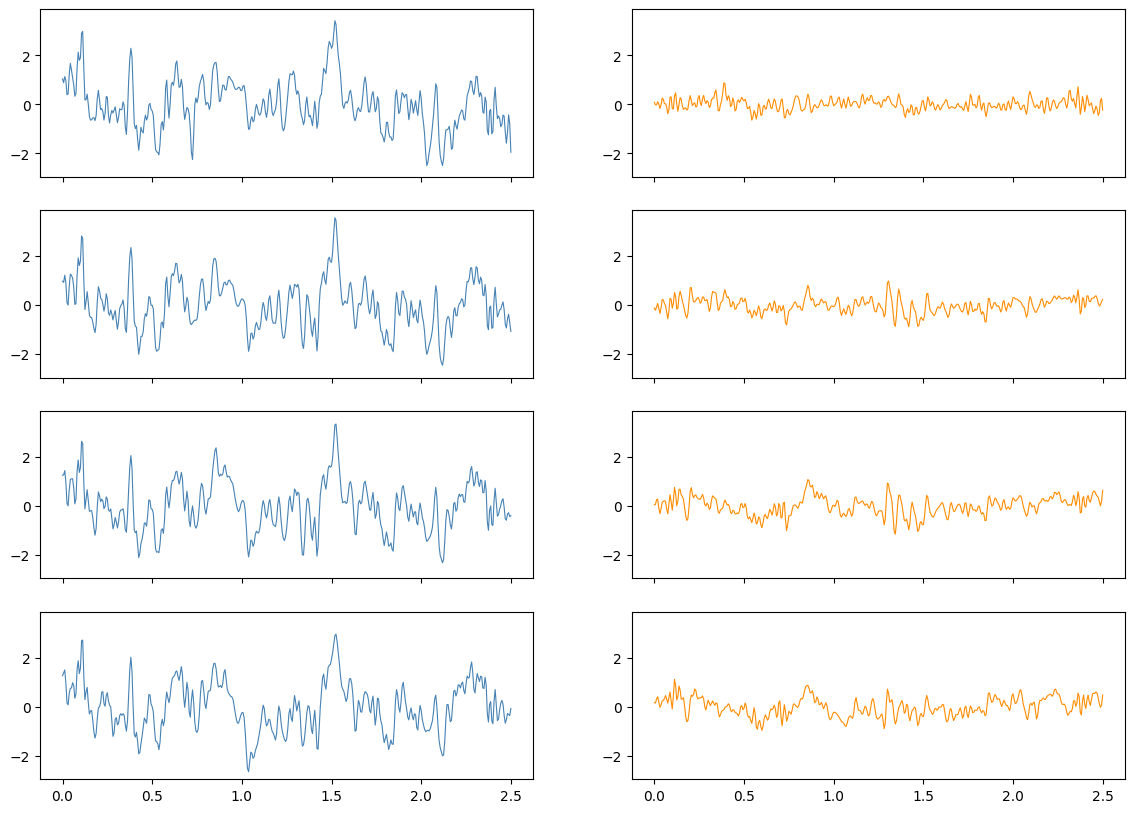

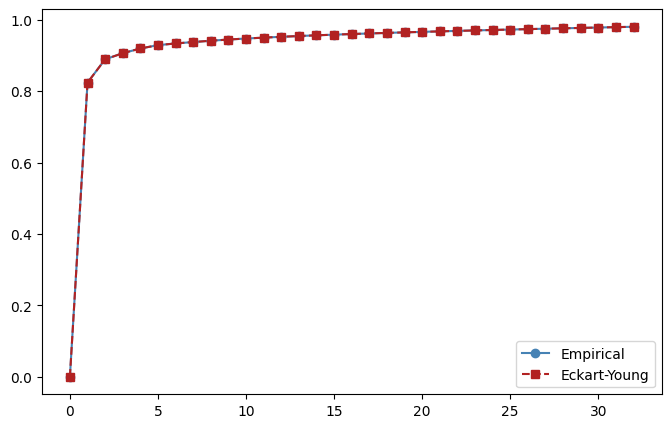

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

from pathlib import Path
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

BD = Path("/content/drive/MyDrive/Group 10 Project/data/processed_subject_epochs")
BS = {"S088", "S092", "S100"}
C = ["left_fist", "right_fist", "both_fists", "both_feet", "rest"]
CD = defaultdict(list)
KS = []

q = []

for d in BD.iterdir():
    q.append(d)

w = []

for d in q:
    is_d = d.is_dir()
    if is_d:
        w.append(d)

z = []

for d in w:
    name = d.name
    starts = name.startswith("S")
    if starts:
        z.append(d)

SD = sorted(z)

for s in SD:

    sn = s.name
    if sn in BS:
        continue

    npz_p = s / "epochs.npz"
    e = npz_p.exists()
    if not e:
        continue

    subj_npz = np.load(npz_p)

    for cond in subj_npz.files:
        CD[cond].append(subj_npz[cond])

    KS.append(sn)

CA = {cond: np.concatenate(arrays, axis=0) for cond, arrays in CD.items()}
K = 27
PM = {}
XSA = {}

for cond in C:

    X = CA[cond].mean(axis=2)
    scaler = StandardScaler()
    XS = scaler.fit_transform(X)
    PF = PCA()
    PF.fit(XS)
    PM[cond] = PF
    XSA[cond] = XS


def REAR(X, pm, kr):
    s = pm.transform(X)
    sr = s.copy()
    sr[:, :kr] = 0
    XR = pm.inverse_transform(sr)
    r = X - XR
    n1 = np.linalg.norm(r, 'fro')
    n2 = np.linalg.norm(X, 'fro')
    res = n1 / n2
    return res

k_vals = list(range(0, 33))
ERR = {}

for cond in C:

    t_list = []

    for k in k_vals:
        val = REAR(XSA[cond], PM[cond], k)
        t_list.append(val)

    ERR[cond] = t_list

cols = {"left_fist": "blue", "right_fist": "orange", "both_fists": "purple", "both_feet": "green", "rest": "gray"}
f1, a1 = plt.subplots(figsize=(10, 6))

for cond in C:
    a1.plot(k_vals, ERR[cond], marker='o', ms=4, label=cond, color=cols[cond])

a1.axvline(K, color='red', linestyle='--', linewidth=1.5)
a1.set_xlabel("Number of top PCs removed")
a1.set_ylabel("Relative reconstruction error (Frobenius norm)")
a1.legend()
plt.show()

f2, axes2 = plt.subplots(1, 5, figsize=(22, 4))

for ax, cond, color in zip(axes2, C, cols.values()):

    m = PM[cond]
    ev = m.explained_variance_ratio_ * 100
    cv = np.cumsum(ev)
    cp = np.arange(1, len(ev) + 1)
    ax.bar(cp, ev, color=color, alpha=0.6)
    ax.plot(cp, cv, 'k--o', ms=2)
    ax.axvspan(0.5, K + 0.5, alpha=0.08, color='red')
    ax.set_title(cond)

plt.show()
CDO = "left_fist"
EIX = 0
KRV = 3
ERW = CA[CDO][EIX]
XT = ERW.T
SCS = StandardScaler()
XTS = SCS.fit_transform(XT)
PT = PCA(n_components=K)
PT.fit(XTS)
ST = PT.transform(XTS)
SCN = ST.copy()
SCN[:, :KRV] = 0
XR = PT.inverse_transform(SCN)

TP = np.arange(401) / 160.0
AV = np.concatenate([XTS[:, :4].ravel(), XR[:, :4].ravel()])
YM = AV.min()
YX = AV.max()
YP = YX - YM
YP2 = YP * 0.05
YL = (YM - YP2, YX + YP2)
f3, axes3 = plt.subplots(4, 2, figsize=(14, 10), sharex=True)

for i, ar in enumerate(axes3):

    ar[0].plot(TP, XTS[:, i], color='steelblue', linewidth=0.8)
    ar[0].set_ylim(YL)
    ar[1].plot(TP, XR[:, i], color='darkorange', linewidth=0.8)
    ar[1].set_ylim(YL)

plt.show()
EV = PM["left_fist"].explained_variance_
TE = np.sum(EV)
EYE = []

for k in k_vals:

    if k > 0:
        sum_ev = np.sum(EV[:k])
        ratio = sum_ev / TE
        val = np.sqrt(ratio)
        EYE.append(val)

    else:
        EYE.append(0)

f4, a4 = plt.subplots(figsize=(8, 5))
a4.plot(k_vals, ERR["left_fist"], 'o-', label='Empirical', color='steelblue')
a4.plot(k_vals, EYE, 's--', label='Eckart-Young', color='firebrick')
a4.legend()
plt.show()